# Задача на Препроцессинг данных и Линейную регрессию

 Дан датасет **California Housing** и стоит задача предсказать медианную стоимость дома в жилом блоке (block group) на основе демографических и географических признаков

## **1.** Подготовка данных и исследовательский анализ

### **1.0.** Загрузка библиотек и дадасета

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression

In [2]:
data = pd.DataFrame(fetch_california_housing().data)
data.columns = fetch_california_housing().feature_names
data["MedHouseVal"] = fetch_california_housing().target

In [3]:
fetch_california_housing().DESCR

'.. _california_housing_dataset:\n\nCalifornia Housing dataset\n--------------------------\n\n**Data Set Characteristics:**\n\n:Number of Instances: 20640\n\n:Number of Attributes: 8 numeric, predictive attributes and the target\n\n:Attribute Information:\n    - MedInc        median income in block group\n    - HouseAge      median house age in block group\n    - AveRooms      average number of rooms per household\n    - AveBedrms     average number of bedrooms per household\n    - Population    block group population\n    - AveOccup      average number of household members\n    - Latitude      block group latitude\n    - Longitude     block group longitude\n\n:Missing Attribute Values: None\n\nThis dataset was obtained from the StatLib repository.\nhttps://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html\n\nThe target variable is the median house value for California districts,\nexpressed in hundreds of thousands of dollars ($100,000).\n\nThis dataset was derived from the 1990 U.S

In [4]:
data

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


### **1.1.** Исследовательский анализ, выдвижение гипотез 

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [6]:
data.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


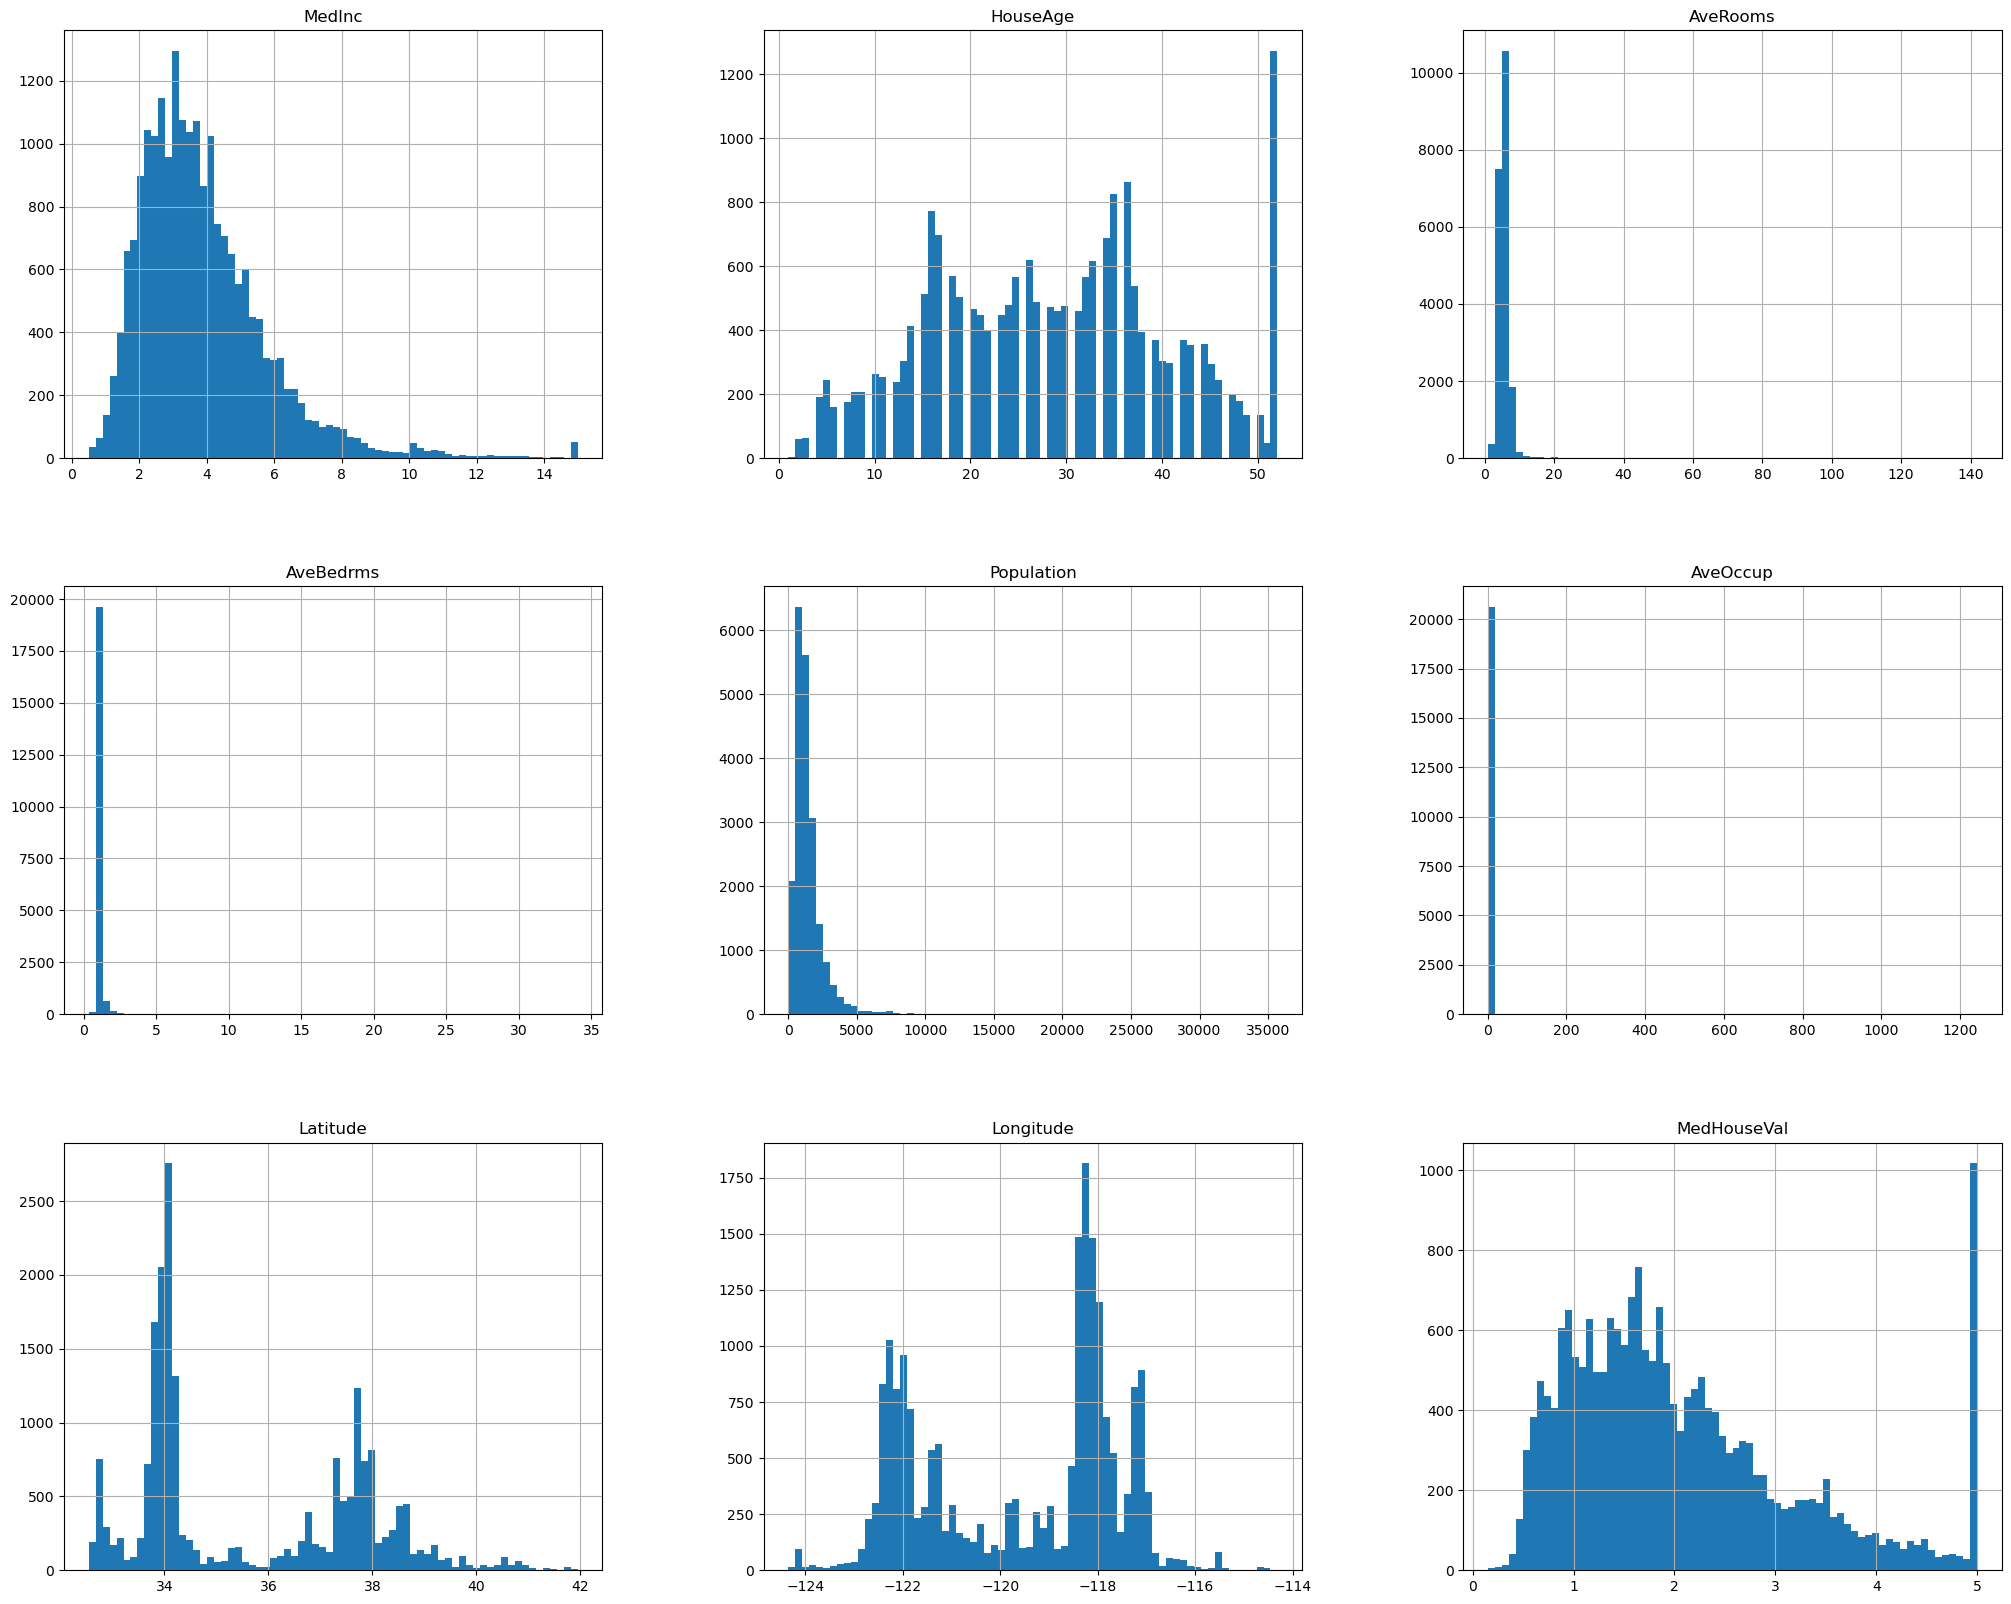

In [8]:
data.hist(bins = 70, figsize = (25,20))
plt.show()

In [105]:
data.duplicated().sum()

np.int64(0)

In [106]:
data.drop_duplicates(inplace = True)

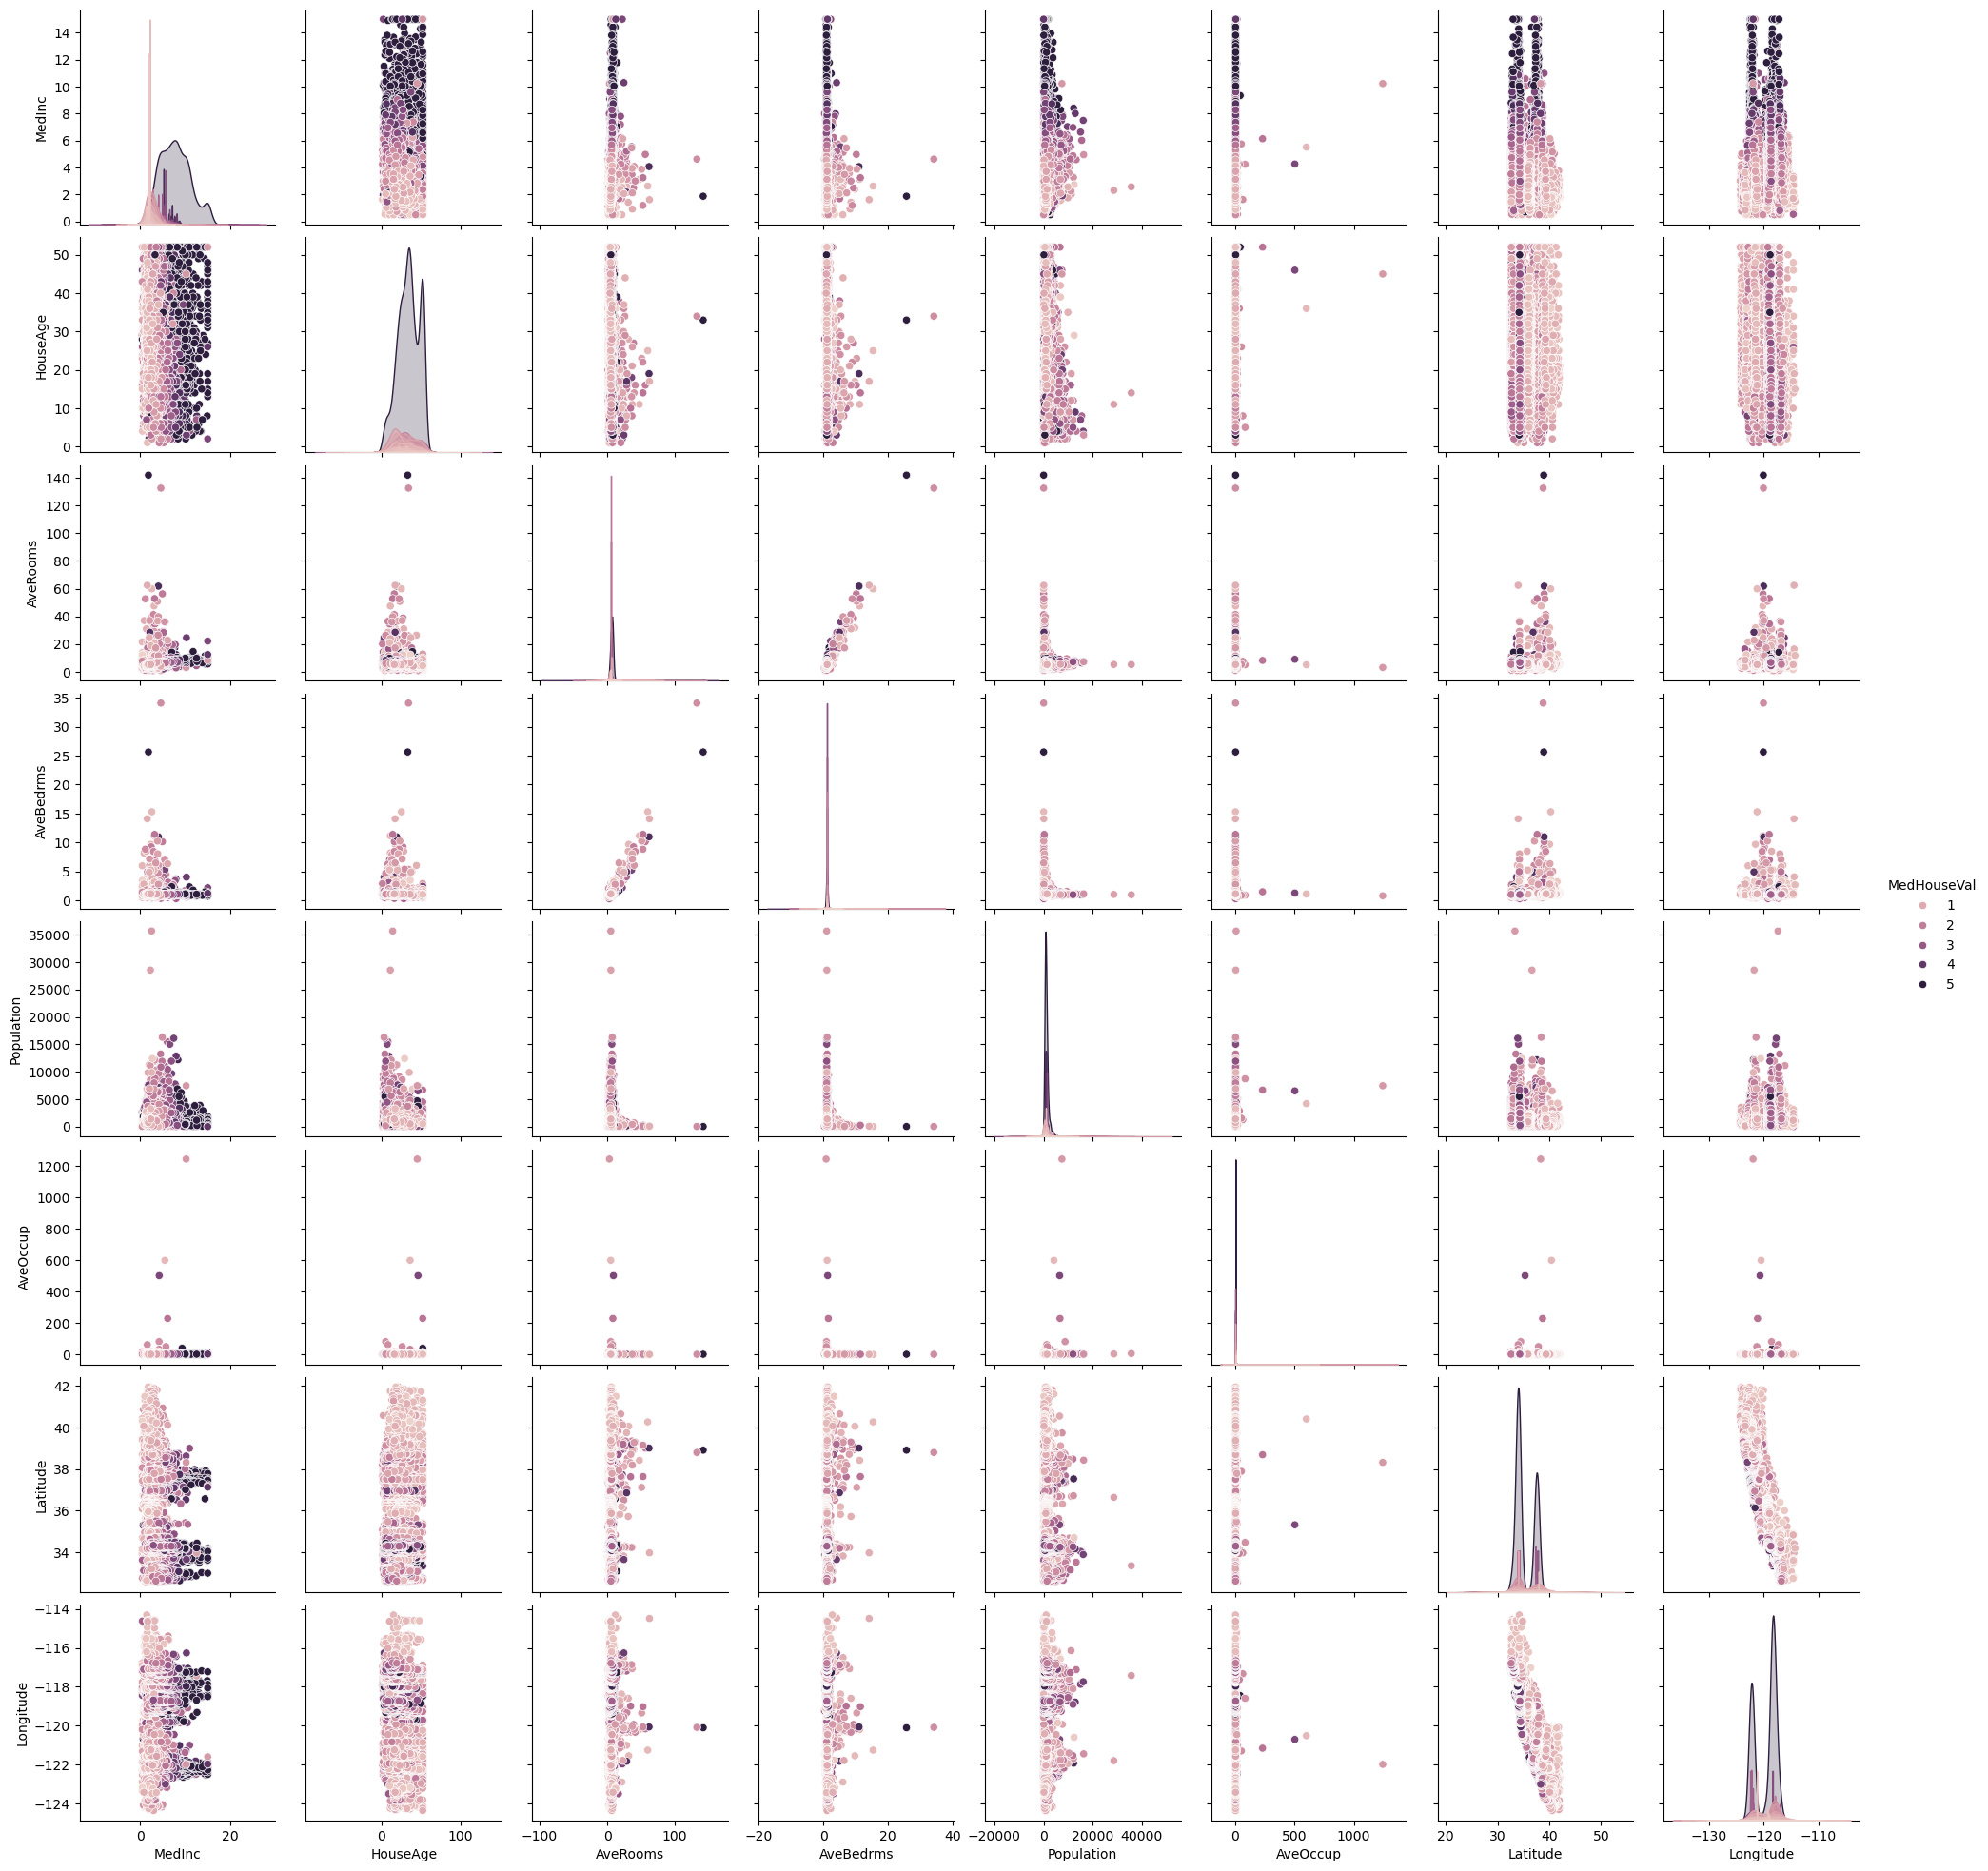

In [120]:
#sns.pairplot(data, hue='MedHouseVal')
#plt.show()

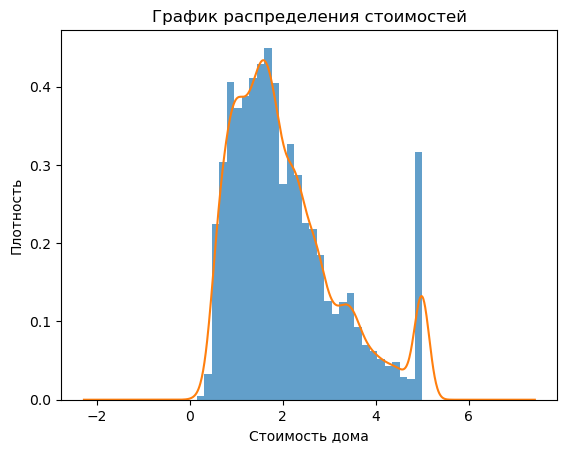

In [10]:
data["MedHouseVal"].hist(bins=30, density=True, alpha=0.7)
data["MedHouseVal"].plot.density()
plt.title("График распределения стоимостей")
plt.xlabel("Стоимость дома")
plt.ylabel("Плотность")
plt.show()

<Axes: >

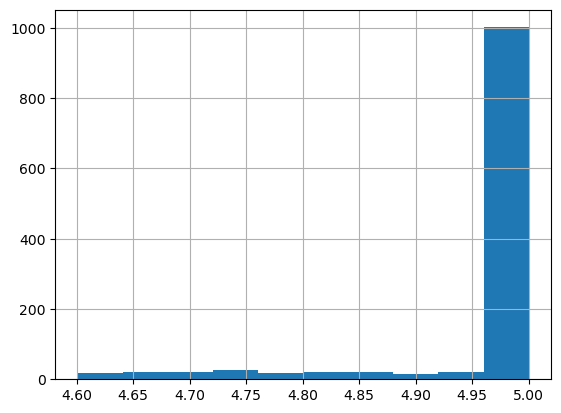

In [108]:
data[data["MedHouseVal"]>4.6].MedHouseVal.hist()

In [109]:
data[data["MedHouseVal"]>4.6].describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,1182.000000,1182.000000,1182.000000,1182.000000,1182.000000,1182.000000,1182.000000,1182.000000,1182.000000
mean,7.508004,33.681895,6.674824,1.091719,1126.328257,2.551297,35.216320,-119.684162,4.966177
std,3.161099,13.056264,4.279073,0.726735,814.058427,1.371093,1.792845,1.959398,0.088914
min,0.499900,2.000000,1.824719,0.500000,13.000000,1.275000,32.630000,-122.710000,4.601000
25%,5.081750,24.250000,5.379809,1.008305,648.000000,2.068849,33.952500,-122.120000,5.000010
50%,7.258300,34.000000,6.750235,1.051415,933.500000,2.507351,34.130000,-118.470000,5.000010
75%,9.775850,44.000000,7.750000,1.100336,1351.750000,2.841346,37.410000,-118.290000,5.000010
max,15.000100,52.000000,141.909091,25.636364,7431.000000,41.214286,38.910000,-116.430000,5.000010


#### Будем отдельно строить модель для данных с дорогими районами и без них

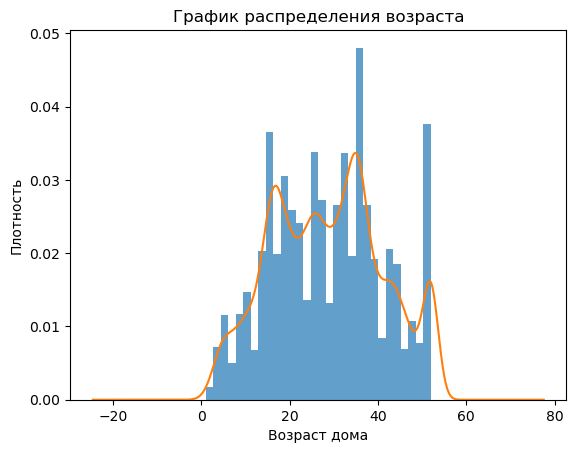

In [13]:
data["HouseAge"].hist(bins=30, density=True, alpha=0.7)
data["HouseAge"].plot.density()
plt.title("График распределения возраста")
plt.xlabel("Возраст дома")
plt.ylabel("Плотность")
plt.show()

<Axes: >

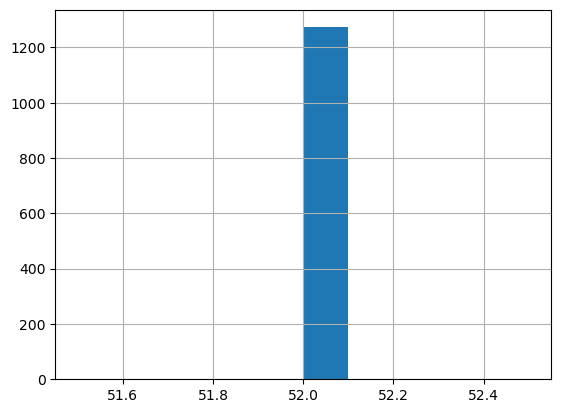

In [14]:
data[data["HouseAge"]>51].HouseAge.hist()

In [15]:
data[data["HouseAge"]>51].describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,1273.000000,1273.0,1273.000000,1273.000000,1273.000000,1273.000000,1273.000000,1273.000000,1273.000000
mean,3.889047,52.0,5.100120,1.066982,934.271013,2.840404,36.605161,-120.885915,2.754209
std,2.307418,0.0,1.399734,0.136465,529.536922,6.560677,1.919859,1.971172,1.390709
min,0.499900,52.0,1.260870,0.444444,8.000000,1.060606,32.660000,-124.350000,0.149990
25%,2.472200,52.0,4.263502,1.009597,591.000000,2.133333,34.120000,-122.410000,1.614000
50%,3.450000,52.0,4.952381,1.052227,879.000000,2.450085,37.750000,-122.220000,2.594000
75%,4.446400,52.0,5.760081,1.100917,1170.000000,2.873239,37.800000,-118.350000,3.804000
max,15.000100,52.0,12.901887,2.932075,6675.000000,230.172414,41.320000,-116.880000,5.000010


### **1.2.** Делим данные на тренировочный и тестовый наборы

In [16]:
data_train, data_test = train_test_split(data)
data_train.shape, data_test.shape

((15480, 9), (5160, 9))

In [17]:
corr_matrix = data_train.corr(method = 'pearson')
corr_matrix

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
MedInc,1.000000,-0.107003,0.300740,-0.062608,-0.003028,0.021841,-0.082875,-0.011694,0.689471
HouseAge,-0.107003,1.000000,-0.146187,-0.076872,-0.288457,0.014091,0.010350,-0.110081,0.116515
AveRooms,0.300740,-0.146187,1.000000,0.864580,-0.074334,-0.004310,0.098533,-0.018603,0.142382
AveBedrms,-0.062608,-0.076872,0.864580,1.000000,-0.066804,-0.006337,0.066964,0.016393,-0.045569
Population,-0.003028,-0.288457,-0.074334,-0.066804,1.000000,0.074803,-0.100222,0.088933,-0.028969
AveOccup,0.021841,0.014091,-0.004310,-0.006337,0.074803,1.000000,-0.001333,0.001159,-0.020229
Latitude,-0.082875,0.010350,0.098533,0.066964,-0.100222,-0.001333,1.000000,-0.924872,-0.147101
Longitude,-0.011694,-0.110081,-0.018603,0.016393,0.088933,0.001159,-0.924872,1.000000,-0.042036
MedHouseVal,0.689471,0.116515,0.142382,-0.045569,-0.028969,-0.020229,-0.147101,-0.042036,1.000000


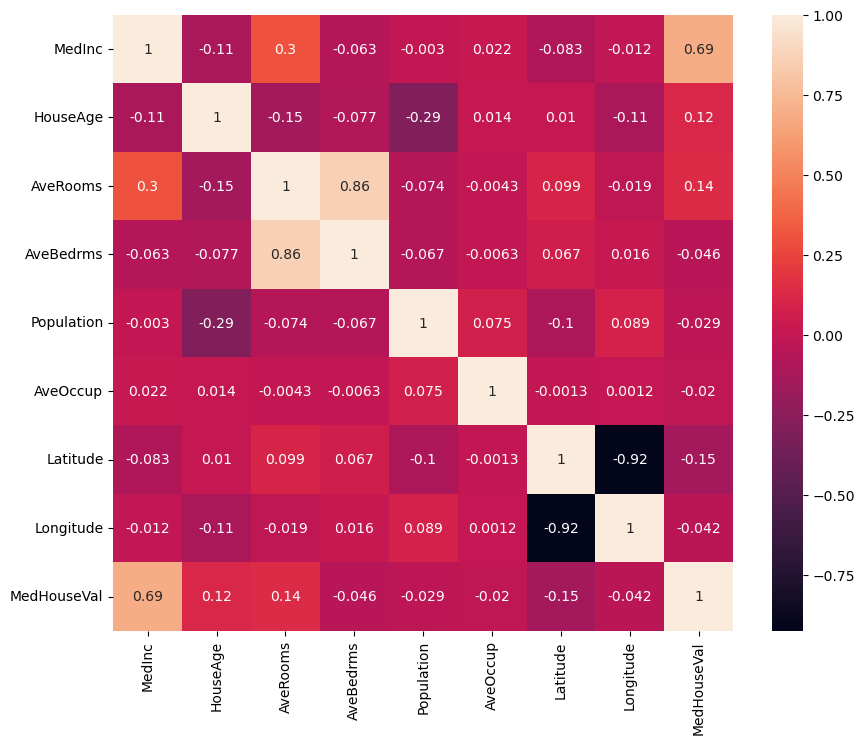

In [18]:
plt.figure(figsize = (10, 8))
sns.heatmap(corr_matrix, annot=True)
plt.show()

In [19]:
corr_matrix["MedHouseVal"].sort_values()

Latitude      -0.147101
AveBedrms     -0.045569
Longitude     -0.042036
Population    -0.028969
AveOccup      -0.020229
HouseAge       0.116515
AveRooms       0.142382
MedInc         0.689471
MedHouseVal    1.000000
Name: MedHouseVal, dtype: float64

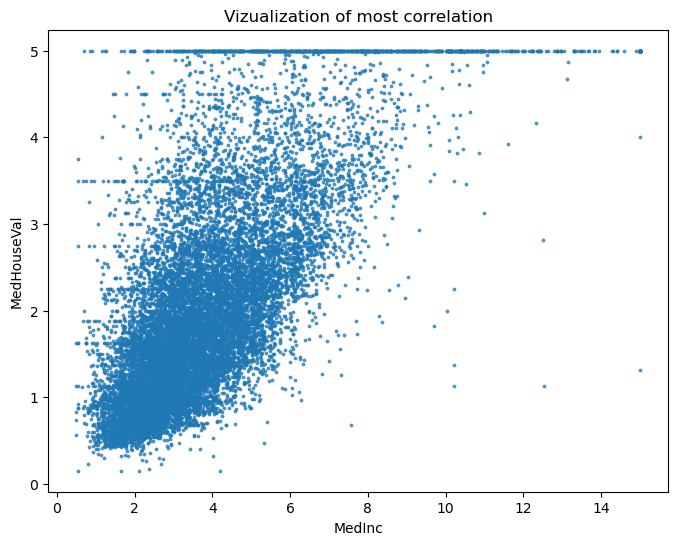

In [20]:
plt.figure(figsize = (8,6))
plt.scatter(data_train["MedInc"], data_train["MedHouseVal"], s=3, alpha=0.7)
plt.xlabel("MedInc")
plt.ylabel("MedHouseVal")
plt.title("Vizualization of most correlation")
plt.show()

In [21]:
data_train.isna().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

In [22]:
data_train.min()

MedInc           0.499900
HouseAge         1.000000
AveRooms         0.888889
AveBedrms        0.333333
Population       3.000000
AveOccup         0.692308
Latitude        32.540000
Longitude     -124.350000
MedHouseVal      0.149990
dtype: float64

In [23]:
data_train[(data_train["AveRooms"]<=1) | (data_train["AveBedrms"]<=1)]

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
13681,4.6445,17.0,6.045618,0.980792,2084.0,2.501801,34.15,-117.23,1.372
3037,4.4196,18.0,5.451613,0.964158,706.0,2.530466,35.38,-119.12,1.210
3449,4.2330,34.0,4.994361,0.968045,1948.0,3.661654,34.32,-118.43,1.574
17476,6.0321,17.0,6.493939,0.981818,1073.0,3.251515,34.44,-119.92,4.026
20140,5.3582,35.0,4.812500,0.937500,334.0,3.479167,34.34,-119.04,2.813
...,...,...,...,...,...,...,...,...,...
2159,2.5804,48.0,5.453172,0.993958,741.0,2.238671,36.77,-119.81,0.789
11546,5.3559,26.0,5.741497,0.954649,1274.0,2.888889,33.74,-118.04,2.358
13658,4.5066,7.0,4.659574,0.952719,1336.0,3.158392,34.06,-117.29,1.115
7505,3.0000,39.0,4.628931,0.949686,1036.0,3.257862,33.92,-118.28,1.100


In [24]:
data_train.columns.tolist()[:-1]

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude']

### **1.3.** Стандартизуем данные методом MinMaxScaler()

In [85]:
mm_scaler = MinMaxScaler()
data_train[data_train.columns.tolist()[:-1]] = mm_scaler.fit_transform(data_train[data_train.columns.tolist()[:-1]])
data_train.sort_index(inplace = True)
data_train

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,0.539668,0.784314,0.043222,0.020469,0.008941,0.001499,0.567481,0.211155,4.526
2,0.466028,1.000000,0.052469,0.021940,0.013818,0.001698,0.564293,0.210159,3.521
3,0.354699,1.000000,0.034949,0.021929,0.015555,0.001493,0.564293,0.209163,3.413
4,0.230776,1.000000,0.038242,0.022166,0.015752,0.001198,0.564293,0.209163,3.422
5,0.243921,1.000000,0.027463,0.022835,0.011491,0.001165,0.564293,0.209163,2.697
...,...,...,...,...,...,...,...,...,...
20630,0.211542,0.196078,0.035766,0.023760,0.035147,0.001716,0.717322,0.301793,1.120
20632,0.181039,0.274510,0.036410,0.022150,0.029261,0.001631,0.714134,0.288845,1.156
20633,0.141350,0.509804,0.032308,0.022091,0.030242,0.001722,0.706695,0.280876,0.983
20637,0.082764,0.313725,0.030610,0.023323,0.028140,0.001314,0.732200,0.311753,0.923


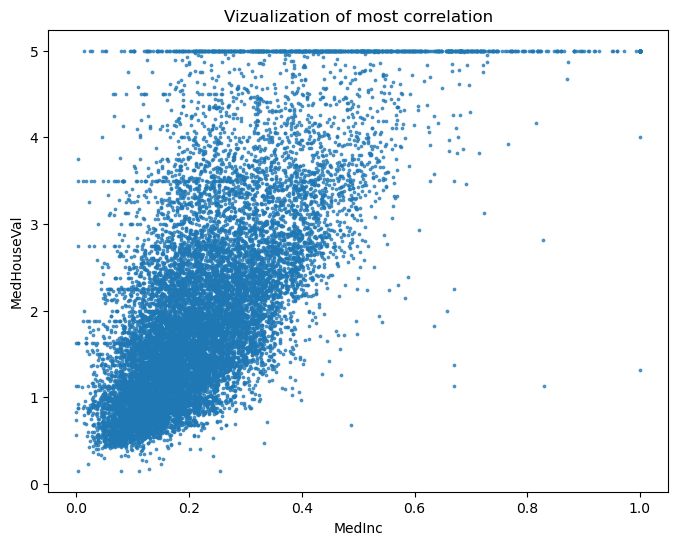

In [26]:
plt.figure(figsize = (8,6))
plt.scatter(data_train["MedInc"], data_train["MedHouseVal"], s=3, alpha=0.7)
plt.xlabel("MedInc")
plt.ylabel("MedHouseVal")
plt.title("Vizualization of most correlation")
plt.show()

In [86]:
data_test[data_test.columns.tolist()[:-1]] = mm_scaler.transform(data_test[data_test.columns.tolist()[:-1]])
data_test.sort_index(inplace = True)
data_test

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
1,0.538027,0.392157,0.097288,0.061038,0.148504,0.001743,0.564430,0.213772,3.585
8,0.108998,0.803922,0.062212,0.075944,0.074345,0.001605,0.562300,0.209661,2.267
11,0.191073,1.000000,0.070843,0.066421,0.092839,0.001642,0.563365,0.209661,2.418
15,0.112074,0.960784,0.061279,0.071273,0.042758,0.002629,0.563365,0.209661,1.400
16,0.156901,1.000000,0.091901,0.068857,0.048715,0.002221,0.563365,0.208633,1.525
...,...,...,...,...,...,...,...,...,...
20631,0.208135,0.274510,0.095622,0.078353,0.073973,0.002859,0.720980,0.298047,1.072
20634,0.221556,0.529412,0.107048,0.079074,0.064106,0.003274,0.714590,0.281603,1.168
20635,0.073130,0.470588,0.075768,0.077548,0.051942,0.002496,0.736954,0.329908,0.781
20636,0.141853,0.333333,0.095049,0.096207,0.021596,0.003435,0.738019,0.317575,0.771


## **2.** Строим модель Линейной регрессии 

### **2.1.** Создаем собственный класс **LinearRegres** для модели линейной регрессии и реализовываем два метода обучения: градиентный спуск и аналитический подход 

In [194]:
class LinearRegres:
    def init(model):
        pass

    def gradientdescent(model, X, iter_cost = 0.01, iterations = 300):
        y = np.array(X["MedHouseVal"])
        X = X.drop(columns = ["MedHouseVal"], axis = 1).to_numpy()
        model.weights, model.bias = np.zeros(X.shape[1]), 0
        costs = []

        for i in range(iterations + 1):
            costs.append((1 / X.shape[0]) * (np.sum((np.dot(X, model.weights) + model.bias - y) ** 2)))
            if i % 100 == 0:
                print(f"Cost at {i} iterations: {costs[-1]}")

            dJ_dw = (2 / X.shape[0]) * np.dot(X.T, (np.dot(X, model.weights) + model.bias - y))
            dJ_db = (2 / X.shape[0]) * np.sum(np.dot(X, model.weights) + model.bias - y)

            model.weights = model.weights - iter_cost * dJ_dw
            model.bias = model.bias - iter_cost * dJ_db

        return model.weights, model.bias, costs
    
    def analyt(model, X):
        y = np.array(X["MedHouseVal"])
        X = np.hstack((X.drop(columns = ["MedHouseVal"], axis = 1).to_numpy(), np.ones([X.shape[0], 1])))
        model.weights = np.dot(np.dot(np.linalg.inv(np.dot(X.T, X)), X.T), y)
        model.bias = model.weights[-1]
        model.weights = model.weights[0:-1]
        return model.weights, model.bias

    def R2_score(model, X):
        y_true = np.array(X["MedHouseVal"])
        y_pred = model.predict(X)
        return 1 - ((np.sum((y_true - y_pred) ** 2)) / (np.sum((y_true - np.mean(y_true)) ** 2)))

    def predict(model, X):
        X = X.drop(columns = ["MedHouseVal"], axis = 1).to_numpy()
        return np.dot(X, model.weights) + model.bias

    def funcloss(model, X):
        y = np.array(X["MedHouseVal"])
        return (1 / X.shape[0]) * (np.sum((model.predict(X) - y) ** 2))

### **2.2.** Обучаем модель аналитическим методом

In [195]:
hypplane_anal = LinearRegres()
weights, bias = hypplane_anal.analyt(data_train)
weights, bias

(array([  6.20680315,   0.48815761, -13.13529388,  19.17346513,
         -0.14968008,  -4.73982006,  -3.98416785,  -4.36478935]),
 np.float64(3.7577168598760657))

In [165]:
loses_on_train = []
loses_on_train.append(hypplane_anal.funcloss(data_train))
loses_on_train[-1]

np.float64(0.5230579017275531)

In [166]:
loses_on_test = []
loses_on_test.append(hypplane_anal.funcloss(data_test))
loses_on_test[-1]

np.float64(0.6625061472411486)

In [218]:
R2_list = []
R2_list.append(hypplane_anal.R2_score(data_test))
R2_list[-1]

np.float64(0.5046423961712418)

### **2.3.** Обучаем модель методом градиентного спуска

In [198]:
hypplane_grad = LinearRegres()
weights, bias, costs = hypplane_grad.gradientdescent(data_train, iter_cost = 0.5, iterations=1500)
weights, bias

Cost at 0 iterations: 5.643652260211491
Cost at 100 iterations: 0.6155387979755758
Cost at 200 iterations: 0.5756567154216748
Cost at 300 iterations: 0.5623962013372633
Cost at 400 iterations: 0.5539328530198934
Cost at 500 iterations: 0.5482214764484019
Cost at 600 iterations: 0.5443207375836139
Cost at 700 iterations: 0.5416237441110628
Cost at 800 iterations: 0.5397306067725378
Cost at 900 iterations: 0.5383771576212533
Cost at 1000 iterations: 0.5373885303472453
Cost at 1100 iterations: 0.5366486711499064
Cost at 1200 iterations: 0.536080298321755
Cost at 1300 iterations: 0.5356317240740582
Cost at 1400 iterations: 0.5352681842298862
Cost at 1500 iterations: 0.5349661298534072


(array([ 5.50292888,  0.52601232,  0.48801199,  1.20177842,  0.04886485,
        -0.51604044, -4.00147028, -4.32448022]),
 np.float64(3.8394983613790465))

In [167]:
loses_on_train.append(hypplane_grad.funcloss(data_train))
loses_on_train[-1]

np.float64(0.5349633605276933)

In [168]:
loses_on_test.append(hypplane_grad.funcloss(data_test))
loses_on_test[-1]

np.float64(0.5501207310185268)

In [219]:
R2_list.append(hypplane_grad.R2_score(data_test))
R2_list[-1]

np.float64(0.5886732700237552)

Text(0.5, 1.0, 'Gradient Descent')

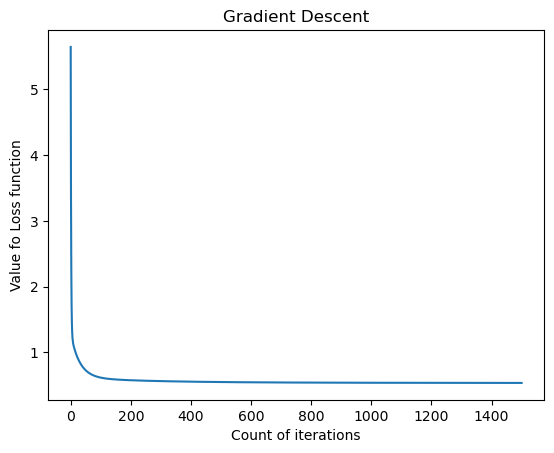

In [82]:
plt.plot(range(1501), costs)
plt.xlabel("Count of iterations")
plt.ylabel("Value fo Loss function")
plt.title("Gradient Descent")

### **2.4.** Обучаем модель при помощи библиотеки **sklearn**

In [91]:
hypplane_sklearn = LinearRegression().fit(data_train.drop(columns = "MedHouseVal", axis = 1), data_train["MedHouseVal"])
hypplane_sklearn.coef_, hypplane_sklearn.intercept_

(array([  6.20680315,   0.48815761, -13.13529388,  19.17346513,
         -0.14968008,  -4.73982006,  -3.98416785,  -4.36478935]),
 np.float64(3.757716859875925))

In [169]:
loses_on_train.append((1/data_train.shape[0]) * np.sum((hypplane_sklearn.predict(data_train.drop(columns = "MedHouseVal", axis = 1)) - np.array(data_train["MedHouseVal"]))**2))
loses_on_train[-1]

np.float64(0.523057901727553)

In [170]:
loses_on_test.append((1/data_test.shape[0]) * np.sum((hypplane_sklearn.predict(data_test.drop(columns = "MedHouseVal", axis = 1)) - np.array(data_test["MedHouseVal"]))**2))
loses_on_test[-1]

np.float64(0.6625061472411254)

In [220]:
y_true = np.array(data_test["MedHouseVal"])
y_pred = np.dot(data_test.drop(columns = ["MedHouseVal"], axis = 1).to_numpy(), hypplane_sklearn.coef_) + hypplane_sklearn.intercept_
R2_list.append(1 - (np.sum((y_true - y_pred) ** 2)) / (np.sum((y_true - np.mean(y_true)) ** 2)))
R2_list[-1]

np.float64(0.5046423961712592)

## **3.** Обучаем модель отдельно для дорогих и недорогих районов

### **3.1.** Обучаем модель для недорогих районов

#### **3.1.1.** Аналитический метод

In [110]:
data_train[data_train["MedHouseVal"]<4.6].count()

MedInc         14587
HouseAge       14587
AveRooms       14587
AveBedrms      14587
Population     14587
AveOccup       14587
Latitude       14587
Longitude      14587
MedHouseVal    14587
dtype: int64

In [203]:
Nonexp_data_train = data_train[data_train["MedHouseVal"]<4.6]
Nonexp_hypplane_anal = LinearRegres()
weights, bias = Nonexp_hypplane_anal.analyt(Nonexp_data_train)
weights, bias

(array([  5.89222515,   0.38345446, -12.65338442,  16.99829782,
          0.18579505,  -4.03555683,  -3.55070093,  -3.94816651]),
 np.float64(3.487802338740101))

In [171]:
loses_on_train.append(Nonexp_hypplane_anal.funcloss(Nonexp_data_train))
loses_on_train[-1]

np.float64(0.37340153493740946)

In [172]:
Nonexp_data_test = data_test[data_test["MedHouseVal"]<4.6]
loses_on_test.append(Nonexp_hypplane_anal.funcloss(Nonexp_data_test))
loses_on_test[-1]

np.float64(0.46653490639098105)

In [221]:
R2_list.append(Nonexp_hypplane_anal.R2_score(Nonexp_data_test))
R2_list[-1]

np.float64(0.4675561454866085)

#### **3.1.2.** Метод градиентного спуска

In [205]:
Nonexp_hypplane_grad = LinearRegres()
weights, bias, costs = Nonexp_hypplane_grad.gradientdescent(Nonexp_data_train, iter_cost = 0.5, iterations=1500)
weights, bias

Cost at 0 iterations: 4.478271675327374
Cost at 100 iterations: 0.47160259858700215
Cost at 200 iterations: 0.41711880523648454
Cost at 300 iterations: 0.4031115840863993
Cost at 400 iterations: 0.39619050508608644
Cost at 500 iterations: 0.39180886491190214
Cost at 600 iterations: 0.38887341085575444
Cost at 700 iterations: 0.38687110129619856
Cost at 800 iterations: 0.385486256463676
Cost at 900 iterations: 0.38451299379234755
Cost at 1000 iterations: 0.3838155335948874
Cost at 1100 iterations: 0.38330403753683606
Cost at 1200 iterations: 0.3829189235510154
Cost at 1300 iterations: 0.3826205659217681
Cost at 1400 iterations: 0.38238251672866697
Cost at 1500 iterations: 0.3821870414942195


(array([ 5.11880312,  0.40016077,  0.23620984,  0.85159136,  0.31631699,
        -0.44494704, -3.64125598, -3.99171794]),
 np.float64(3.6429091227831276))

In [173]:
loses_on_train.append(Nonexp_hypplane_grad.funcloss(Nonexp_data_train))
loses_on_train[-1]

np.float64(0.3821852575382427)

In [174]:
loses_on_test.append(Nonexp_hypplane_grad.funcloss(Nonexp_data_test))
loses_on_test[-1]

np.float64(0.389644750395332)

In [222]:
R2_list.append(Nonexp_hypplane_grad.R2_score(Nonexp_data_test))
R2_list[-1]

np.float64(0.5553088312377359)

#### **3.1.3.** Библиотека **sklearn**

In [113]:
Nonexp_hypplane = LinearRegression().fit(Nonexp_data_train.drop(columns = "MedHouseVal", axis = 1), Nonexp_data_train["MedHouseVal"])
Nonexp_hypplane.coef_, Nonexp_hypplane.intercept_

(array([  5.89222515,   0.38345446, -12.65338442,  16.99829782,
          0.18579505,  -4.03555683,  -3.55070093,  -3.94816651]),
 np.float64(3.487802338739974))

In [175]:
loses_on_train.append((1/Nonexp_data_train.shape[0]) * np.sum((Nonexp_hypplane.predict(Nonexp_data_train.drop(columns = "MedHouseVal", axis = 1)) - np.array(Nonexp_data_train["MedHouseVal"]))**2))
loses_on_train[-1]

np.float64(0.3734015349374094)

In [176]:
loses_on_test.append((1/Nonexp_data_test.shape[0]) * np.sum((Nonexp_hypplane.predict(Nonexp_data_test.drop(columns = "MedHouseVal", axis = 1)) - np.array(Nonexp_data_test["MedHouseVal"]))**2))
loses_on_test[-1]

np.float64(0.4665349063909693)

In [223]:
y_true_Nonexp = np.array(Nonexp_data_test["MedHouseVal"])
y_pred_Nonexp = np.dot(Nonexp_data_test.drop(columns = ["MedHouseVal"], axis = 1).to_numpy(), Nonexp_hypplane.coef_) + Nonexp_hypplane.intercept_
R2_list.append(1 - (np.sum((y_true_Nonexp - y_pred_Nonexp) ** 2)) / (np.sum((y_true_Nonexp - np.mean(y_true_Nonexp)) ** 2)))
R2_list[-1]

np.float64(0.46755614548662194)

### **3.2.** Обучаем модель для дорогих районов

#### **3.2.1.** Аналитический метод

In [115]:
data_train[data_train["MedHouseVal"]>=4.6].count()

MedInc         893
HouseAge       893
AveRooms       893
AveBedrms      893
Population     893
AveOccup       893
Latitude       893
Longitude      893
MedHouseVal    893
dtype: int64

In [208]:
Exp_data_train = data_train[data_train["MedHouseVal"]>=4.6]
Exp_hypplane_anal = LinearRegres()
weights, bias = Exp_hypplane_anal.analyt(Exp_data_train)
weights, bias

(array([ 0.08961751,  0.01626548, -0.49766538,  0.90735584, -0.1224038 ,
        -5.1874742 , -0.27211533, -0.27817769]),
 np.float64(5.131449459202134))

In [177]:
loses_on_train.append(Exp_hypplane_anal.funcloss(Exp_data_train))
loses_on_train[-1]

np.float64(0.0075927534201015905)

In [178]:
Exp_data_test = data_test[data_test["MedHouseVal"]>=4.6]
loses_on_test.append(Exp_hypplane_anal.funcloss(Exp_data_test))
loses_on_test[-1]

np.float64(0.009697959081058288)

In [224]:
R2_list.append(Exp_hypplane_anal.R2_score(Exp_data_test))
R2_list[-1]

np.float64(-0.04976002222929665)

#### **3.2.2.** Метод градиентного спуска

In [210]:
Exp_hypplane_grad = LinearRegres()
weights, bias, costs = Exp_hypplane_grad.gradientdescent(Exp_data_train, iter_cost = 0.5, iterations=1500)
weights, bias

Cost at 0 iterations: 24.67994183658847
Cost at 100 iterations: 0.04257840169571615
Cost at 200 iterations: 0.009668573513550651
Cost at 300 iterations: 0.009449804007149877
Cost at 400 iterations: 0.009305689840750453
Cost at 500 iterations: 0.009184638138303749
Cost at 600 iterations: 0.00908075675389884
Cost at 700 iterations: 0.008989889579019526
Cost at 800 iterations: 0.008909064475926308
Cost at 900 iterations: 0.008836145061596502
Cost at 1000 iterations: 0.00876958551892403
Cost at 1100 iterations: 0.008708257883928516
Cost at 1200 iterations: 0.00865133035693513
Cost at 1300 iterations: 0.008598181536849447
Cost at 1400 iterations: 0.008548339948325361
Cost at 1500 iterations: 0.008501441378651529


(array([ 0.05800125,  0.02223538, -0.19229159, -0.06608365,  0.0748891 ,
        -0.00238535,  0.86406235,  0.83425278]),
 np.float64(4.297643430459463))

In [179]:
loses_on_train.append(Exp_hypplane_grad.funcloss(Exp_data_train))
loses_on_train[-1]

np.float64(0.008500986231221334)

In [180]:
loses_on_test.append(Exp_hypplane_grad.funcloss(Exp_data_test))
loses_on_test[-1]

np.float64(0.009814716706874758)

In [225]:
R2_list.append(Exp_hypplane_grad.R2_score(Exp_data_test))
R2_list[-1]

np.float64(-0.062398504908805164)

#### **3.2.3.** Библиотека **sklearn**

In [118]:
Exp_hypplane = LinearRegression().fit(Exp_data_train.drop(columns = "MedHouseVal", axis = 1), Exp_data_train["MedHouseVal"])
Exp_hypplane.coef_, Exp_hypplane.intercept_

(array([ 0.08961751,  0.01626548, -0.49766538,  0.90735584, -0.1224038 ,
        -5.1874742 , -0.27211533, -0.27817769]),
 np.float64(5.131449459201232))

In [181]:
loses_on_train.append((1/Exp_data_train.shape[0]) * np.sum((Exp_hypplane.predict(Exp_data_train.drop(columns = "MedHouseVal", axis = 1)) - np.array(Exp_data_train["MedHouseVal"]))**2))
loses_on_train[-1]

np.float64(0.007592753420101587)

In [182]:
loses_on_test.append((1/Exp_data_test.shape[0]) * np.sum((Exp_hypplane.predict(Exp_data_test.drop(columns = "MedHouseVal", axis = 1)) - np.array(Exp_data_test["MedHouseVal"]))**2))
loses_on_test[-1]

np.float64(0.009697959081215637)

In [226]:
y_true_Exp = np.array(Exp_data_test["MedHouseVal"])
y_pred_Exp = np.dot(Exp_data_test.drop(columns = ["MedHouseVal"], axis = 1).to_numpy(), Exp_hypplane.coef_) + Exp_hypplane.intercept_
R2_list.append(1 - (np.sum((y_true_Exp - y_pred_Exp) ** 2)) / (np.sum((y_true_Exp - np.mean(y_true_Exp)) ** 2)))
R2_list[-1]

np.float64(-0.04976002224632903)

In [239]:
(1/Exp_data_test.shape[0]) * (np.sum((Exp_data_train["MedHouseVal"].mean() - Exp_data_test["MedHouseVal"])**2))  #!!!

np.float64(0.00929459458805973)

In [240]:
(1 - np.sum((Exp_data_test["MedHouseVal"] - Exp_data_train["MedHouseVal"].mean()) ** 2)) / np.sum((Exp_data_test["MedHouseVal"] - np.mean(Exp_data_test["MedHouseVal"])) ** 2)

np.float64(-0.6353940247212344)

## 4. Выводы

In [183]:
loses_on_train

[np.float64(0.5230579017275531),
 np.float64(0.5349633605276933),
 np.float64(0.523057901727553),
 np.float64(0.37340153493740946),
 np.float64(0.3821852575382427),
 np.float64(0.3734015349374094),
 np.float64(0.0075927534201015905),
 np.float64(0.008500986231221334),
 np.float64(0.007592753420101587)]

In [184]:
loses_on_test

[np.float64(0.6625061472411486),
 np.float64(0.5501207310185268),
 np.float64(0.6625061472411254),
 np.float64(0.46653490639098105),
 np.float64(0.389644750395332),
 np.float64(0.4665349063909693),
 np.float64(0.009697959081058288),
 np.float64(0.009814716706874758),
 np.float64(0.009697959081215637)]

In [227]:
R2_list

[np.float64(0.5046423961712418),
 np.float64(0.5886732700237552),
 np.float64(0.5046423961712592),
 np.float64(0.4675561454866085),
 np.float64(0.5553088312377359),
 np.float64(0.46755614548662194),
 np.float64(-0.04976002222929665),
 np.float64(-0.062398504908805164),
 np.float64(-0.04976002224632903)]

In [228]:
table = pd.DataFrame(data = [loses_on_train, loses_on_test, R2_list], index = ["MSE on train", "MSE on test", "R2 on test"], columns = ["Analyt All", "Gradient All", "Sklearn All", "Analyt Nonexp", "Gradient Nonexp", "Sklearn Nonexp", "Analyt Exp", "Gradient Exp", "Sklearn Exp"])
table

,Analyt All,Gradient All,Sklearn All,Analyt Nonexp,Gradient Nonexp,Sklearn Nonexp,Analyt Exp,Gradient Exp,Sklearn Exp
MSE on train,0.523058,0.534963,0.523058,0.373402,0.382185,0.373402,0.007593,0.008501,0.007593
MSE on test,0.662506,0.550121,0.662506,0.466535,0.389645,0.466535,0.009698,0.009815,0.009698
R2 on test,0.504642,0.588673,0.504642,0.467556,0.555309,0.467556,-0.049760,-0.062399,-0.049760


* Реализованный собственноручно аналитический подход к обучению модели полностью идентичен предложенный библиотекой sklearn;
* Во всех трёх сформированных датасетах (все дома, только дорогие, только недорогие) метод обучения градиентным спуском приводит к более лучшей функции потерь по сравнении с аналитическим подходом (тот же Linear Regression из sklearn). Исключением является лишь небольшой датасет (всего 893 элемента в обучающей выборке) с дорогими домами, в котором аналитический подход дал не намного, но лучше показатели;
* Модель построенная тремя подходами (фактически двумя) во всех трёх случаях показала себя на тренировочной выборке лучше чем на тестовой выборке, то есть на выборке, которую она еще не видела (что вполне закономерно);
* Разделение исходного датасета на два датасета по критерию дороговизны дома (что было решено на основе графика распределения стоимости домов на всём наборе данных) привёл к заметному улучшению качества оценки модели;
* Модель обученная на данных для дорогих домов показала фантастические результаты на по метрике MSE (минимальная квадратичная ошибка), но достаточно печальные по метрике R2, что является закономерным следствием маленького обьема данных (893 элемента на тренировочном наборе) и ничтожным разнообразием цен домов (фактически цены варьируются от 4.6 до 5.1, а стандартное отклонение составляет ничтожные 0.089). Это непосредственно означает, что модели попросту нечего оценивать, целевая переменная почти константа, и ничего бы не стоило (а даже было бы качественнее 0.0093 < 0.0097) заменить нашу модель на постоянное предсказание среднего значения на данной выборке